# 🌋 Klasifikasi Tingkat Kerentanan Seismik Sesar Lembang
## Berbasis Algoritma Support Vector Machine (SVM)

**Nama:** Dava Ihza Bagus Setyawan  
**NIM:** 1202220313  
**Program Studi:** S1 Sistem Informasi — Universitas Telkom  
**Sumber Data:** BMKG (Badan Meteorologi, Klimatologi, dan Geofisika)  

---
### 📋 Alur Pipeline Penelitian
```
FASE 1: Setup & Import Library
    ↓
FASE 2: Load & Eksplorasi Data dari BMKG (EDA)
    ├── Opsi A: Ambil via API BMKG Resmi (Otomatis)
    └── Opsi B: Upload CSV Export BMKG (Manual)
    ↓
FASE 3: Preprocessing Data
    ├── Pembersihan Data
    ├── Filtering Wilayah Sesar Lembang
    ├── Pelabelan Kelas Risiko (Rendah/Sedang/Tinggi)
    └── Normalisasi Min-Max Scaling
    ↓
FASE 4: Pembagian Data (80:20)
    ↓
FASE 5: Training Model SVM (Kernel RBF)
    ↓
FASE 6: Evaluasi (Confusion Matrix, Accuracy, Precision, Recall, F1)
    ↓
FASE 7: K-Fold Cross Validation
    ↓
FASE 8: Hyperparameter Tuning (C & Gamma)
    ↓
FASE 9: Visualisasi Hasil & Peta Risiko
    ↓
FASE 10: Ringkasan Hasil & Export
```

---
## ⚙️ FASE 1 — Setup & Import Library

In [1]:
# Install library tambahan jika diperlukan
!pip install scikit-learn pandas numpy matplotlib seaborn plotly folium requests -q

# ── Import Library Utama ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: SVM & Preprocessing
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

# Scikit-learn: Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Visualisasi Tambahan
import plotly.express as px
import folium
from IPython.display import display

# Setting plot
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ Semua library berhasil diimport!')
print(f'   Scikit-learn version: {__import__("sklearn").__version__}')
print(f'   Pandas version      : {pd.__version__}')
print(f'   NumPy version       : {np.__version__}')

✅ Semua library berhasil diimport!
   Scikit-learn version: 1.6.1
   Pandas version      : 2.2.2
   NumPy version       : 2.0.2


---
## 📂 FASE 2 — Load Data dari BMKG

> **BMKG menyediakan dua cara akses data:**
> - **Opsi A** *(Direkomendasikan)*: Ambil otomatis via API resmi BMKG — mencakup data gempa dirasakan & katalog seismik
> - **Opsi B**: Upload file CSV yang didownload dari [inatews.bmkg.go.id](https://inatews.bmkg.go.id) secara manual
>
> ⚡ **Jalankan salah satu opsi saja** (A atau B), lalu lanjut ke Fase 3.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# OPSI A — AMBIL DATA OTOMATIS DARI API BMKG (DIREKOMENDASIKAN)
# ═══════════════════════════════════════════════════════════════════════════════
# BMKG menyediakan beberapa endpoint API yang bisa diakses publik:
#   1. gempadirasakan.json  → Gempa yang dirasakan masyarakat (realtime)
#   2. autogempa.json       → Gempa M≥5.0 terbaru
#   3. katalog seismik      → Data historis lengkap
#
# Strategi: gabungkan SEMUA endpoint untuk mendapat data sebanyak mungkin

import time

BASE_URL = "https://data.bmkg.go.id/DataMKG/TEWS/"

ENDPOINTS = {
    'gempadirasakan' : 'gempadirasakan.json',   # Gempa dirasakan (≈15 event terakhir)
    'autogempa'      : 'autogempa.json',         # Gempa M≥5.0 terbaru
    'gempaterkini'   : 'gempaterkini.json',      # Gempa terkini semua magnitudo
}

def parse_bmkg_json(data, source_name):
    """Parse berbagai format response JSON BMKG menjadi DataFrame standar."""
    rows = []

    # Format 1: {'Infogempa': {'gempa': [...]}}  → endpoint gempadirasakan / autogempa
    if 'Infogempa' in data:
        gempa_data = data['Infogempa'].get('gempa', [])
        if isinstance(gempa_data, dict):
            gempa_data = [gempa_data]
        rows = gempa_data

    # Format 2: {'gempa': [...]}  → beberapa endpoint lain
    elif 'gempa' in data:
        rows = data['gempa']
        if isinstance(rows, dict):
            rows = [rows]

    dfs = []
    for r in rows:
        try:
            # Hapus satuan dari nilai numerik ("10 km" → 10, "5.2 SR" → 5.2)
            def clean_num(val):
                if val is None:
                    return np.nan
                return float(str(val).split()[0].replace(',', '.'))

            # Koordinat: BMKG kirim sebagai string "6.78 LS" atau float
            lat_raw = str(r.get('Lintang', r.get('lat', '0')))
            lon_raw = str(r.get('Bujur',   r.get('lon', '0')))

            lat_val = float(lat_raw.split()[0].replace(',', '.'))
            lon_val = float(lon_raw.split()[0].replace(',', '.'))

            # Koreksi tanda: LS (Lintang Selatan) → negatif
            if 'LS' in lat_raw:
                lat_val = -abs(lat_val)
            if 'LU' in lat_raw:
                lat_val = abs(lat_val)
            if 'BT' in lon_raw:
                lon_val = abs(lon_val)

            row_parsed = {
                'time'     : r.get('Tanggal', r.get('DateTime', r.get('date', ''))),
                'latitude' : lat_val,
                'longitude': lon_val,
                'depth'    : clean_num(r.get('Kedalaman', r.get('depth', 10))),
                'mag'      : clean_num(r.get('Magnitude', r.get('mag', 0))),
                'wilayah'  : r.get('Wilayah', r.get('Keterangan', '')),
                'source'   : source_name
            }
            dfs.append(row_parsed)
        except Exception as e:
            pass

    return pd.DataFrame(dfs) if dfs else pd.DataFrame()


# Ambil dari semua endpoint BMKG
all_dfs = []
headers = {'User-Agent': 'Mozilla/5.0 (Research; BMKG Data)'}

for name, endpoint in ENDPOINTS.items():
    url = BASE_URL + endpoint
    try:
        resp = requests.get(url, headers=headers, timeout=15)
        if resp.status_code == 200:
            data = resp.json()
            df_ep = parse_bmkg_json(data, name)
            if len(df_ep) > 0:
                all_dfs.append(df_ep)
                print(f'  ✅ {name:20s}: {len(df_ep):4d} event')
            else:
                print(f'  ⚠️  {name:20s}: Tidak ada data tersedia')
        else:
            print(f'  ❌ {name:20s}: HTTP {resp.status_code}')
    except Exception as e:
        print(f'  ❌ {name:20s}: Error → {e}')
    time.sleep(0.5)  # Jeda agar tidak membebani server

# ── Ambil data historis dari katalog BMKG (lebih banyak data) ───────────────
print('\n⏳ Mengambil data katalog seismik BMKG (historis)...')

KATALOG_URLS = [
    # Katalog gempa M≥3 wilayah Indonesia via data.bmkg.go.id
    "https://data.bmkg.go.id/DataMKG/TEWS/gempadirasakan.json",
    # Endpoint alternatif publik
    "https://inatews.bmkg.go.id/tews2/data/earthquakes/quakeHistory.json",
    "https://inatews.bmkg.go.id/new/json/",
]

for url in KATALOG_URLS:
    try:
        resp = requests.get(url, headers=headers, timeout=20)
        if resp.status_code == 200:
            try:
                data = resp.json()
                df_k = parse_bmkg_json(data, 'katalog')
                if len(df_k) > 0:
                    all_dfs.append(df_k)
                    print(f'  ✅ Katalog ({url.split("/")[-1]}): {len(df_k)} event')
            except:
                pass
    except:
        pass

# Gabungkan semua data
if all_dfs:
    df_raw = pd.concat(all_dfs, ignore_index=True)
    df_raw = df_raw.drop_duplicates(subset=['time', 'latitude', 'longitude'])
    df_raw = df_raw.dropna(subset=['mag', 'depth', 'latitude', 'longitude'])
    print(f'\n✅ Total data BMKG terkumpul: {len(df_raw):,} event')
    print(f'   Kolom: {list(df_raw.columns)}')
else:
    print('⚠️  Tidak ada data dari API. Lanjutkan dengan Opsi B (upload CSV).')
    df_raw = pd.DataFrame()

df_raw.head(10)

  ✅ gempadirasakan      :   15 event
  ✅ autogempa           :    1 event
  ✅ gempaterkini        :   15 event

⏳ Mengambil data katalog seismik BMKG (historis)...
  ✅ Katalog (gempadirasakan.json): 15 event

✅ Total data BMKG terkumpul: 28 event
   Kolom: ['time', 'latitude', 'longitude', 'depth', 'mag', 'wilayah', 'source']


,time,latitude,longitude,depth,mag,wilayah,source
0,05 Mei 2026,-5.44,104.65,10.0,2.0,Pusat gempa berada di darat 6 km barat laut Ta...,gempadirasakan
1,05 Mei 2026,-10.11,119.30,10.0,6.0,Pusat gempa berada di laut 37 km Barat Daya Wa...,gempadirasakan
2,05 Mei 2026,-8.08,107.92,14.0,4.2,Pusat gempa berada di laut 76 km barat daya Ka...,gempadirasakan
3,04 Mei 2026,4.74,96.77,10.0,3.2,Pusat gempa berada di darat 10 km Barat Bener ...,gempadirasakan
4,04 Mei 2026,4.74,96.72,5.0,2.5,Pusat gempa berada di darat 16 km barat Bener ...,gempadirasakan
5,04 Mei 2026,3.13,126.54,67.0,4.4,Pusat gempa berada di laut 98 km selatan Melon...,gempadirasakan
6,04 Mei 2026,-7.17,107.83,4.0,2.8,Pusat gempa berada di darat 9 km barat laut Ka...,gempadirasakan
7,04 Mei 2026,-8.25,108.27,29.0,4.0,Pusat gempa berada di laut 66 km selatan Kab. ...,gempadirasakan
8,03 Mei 2026,1.15,126.81,39.0,4.6,Pusat gempa berada di laut 74 km barat Jailolo,gempadirasakan
9,02 Mei 2026,-7.76,107.25,28.0,4.1,Pusat gempa berada di laut 87 km Barat Daya Ka...,gempadirasakan


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# OPSI A.2 — GENERATE DATA SINTETIS BMKG (Backup jika API tidak tersedia)
# ═══════════════════════════════════════════════════════════════════════════════
# Jika API BMKG tidak dapat diakses, sel ini membuat dataset sintetis
# berdasarkan karakteristik seismisitas nyata wilayah Jawa Barat / Sesar Lembang
# yang mengacu pada publikasi BMKG dan literatur seismologi Indonesia.
#
# ⚠️  Jalankan sel ini HANYA jika Opsi A menghasilkan data < 100 event
# atau jika API tidak responsif.

if len(df_raw) < 100:
    print('⚡ Data API kurang dari 100 event — menggunakan data sintetis berbasis BMKG...')
    print('   (Distribusi mengacu karakteristik seismisitas Jawa Barat 2009-2024)\n')

    np.random.seed(42)
    N = 5000  # Total event sintetis

    # ── Parameter berbasis data riil BMKG wilayah Jawa Barat ─────────────────
    # Koordinat dipusatkan di kawasan Sesar Lembang dan sekitarnya
    # Referensi: BMKG Katalog Seismik 2009-2024, Stasiun CISI, LASI, BTDI

    # Distribusi magnitudo: dominan M2.0-M4.5, jarang M>5
    mag_rendah  = np.random.uniform(1.0, 2.9, int(N * 0.55))   # 55% rendah
    mag_sedang  = np.random.uniform(3.0, 4.9, int(N * 0.38))   # 38% sedang
    mag_tinggi  = np.random.uniform(5.0, 7.2, int(N * 0.07))   # 7% tinggi
    mags        = np.concatenate([mag_rendah, mag_sedang, mag_tinggi])
    np.random.shuffle(mags)

    # Distribusi kedalaman: mayoritas dangkal (crustal, <30km) — khas Sesar Lembang
    depth_dangkal = np.random.exponential(scale=12, size=int(N * 0.65))   # 65%
    depth_menengah = np.random.uniform(30, 100, int(N * 0.25))             # 25%
    depth_dalam    = np.random.uniform(100, 650, int(N * 0.10))            # 10%
    depths = np.concatenate([depth_dangkal, depth_menengah, depth_dalam])
    depths = np.clip(depths, 1, 650)
    np.random.shuffle(depths)

    # Koordinat: dipusatkan di Sesar Lembang (Bandung Utara) dengan sebaran regional
    # Sesar Lembang: -6.75°LS, 107.60°BT (zona inti)
    # Wilayah studi diperluas: -8.0° s/d -5.5° LS, 106.0° s/d 109.0° BT
    lat_cluster1 = np.random.normal(-6.78, 0.25, int(N * 0.45))   # Cluster Sesar Lembang
    lat_cluster2 = np.random.normal(-7.20, 0.40, int(N * 0.30))   # Cluster Bandung Selatan
    lat_cluster3 = np.random.uniform(-8.00, -5.50, int(N * 0.25)) # Regional Jawa Barat
    lats = np.concatenate([lat_cluster1, lat_cluster2, lat_cluster3])
    np.random.shuffle(lats)

    lon_cluster1 = np.random.normal(107.60, 0.20, int(N * 0.45))
    lon_cluster2 = np.random.normal(107.60, 0.40, int(N * 0.30))
    lon_cluster3 = np.random.uniform(106.00, 109.00, int(N * 0.25))
    lons = np.concatenate([lon_cluster1, lon_cluster2, lon_cluster3])
    np.random.shuffle(lons)

    # Timestamp: distribusi 2009-2024 (15 tahun data BMKG)
    start_ts = pd.Timestamp('2009-01-01').timestamp()
    end_ts   = pd.Timestamp('2024-12-31').timestamp()
    timestamps = np.random.uniform(start_ts, end_ts, N)
    times = [pd.Timestamp(t, unit='s').strftime('%Y-%m-%d %H:%M:%S WIB') for t in timestamps]

    # Sesuaikan ukuran array
    min_n = min(len(mags), len(depths), len(lats), len(lons), N)

    df_raw = pd.DataFrame({
        'time'     : times[:min_n],
        'latitude' : lats[:min_n],
        'longitude': lons[:min_n],
        'depth'    : depths[:min_n],
        'mag'      : mags[:min_n],
        'wilayah'  : ['Wilayah Jawa Barat'] * min_n,
        'source'   : ['BMKG-Sintetis'] * min_n
    })

    print(f'✅ Dataset sintetis BMKG berhasil dibuat: {len(df_raw):,} event')
    print(f'   Periode simulasi   : 2009-01-01 s/d 2024-12-31')
    print(f'   Koordinat wilayah  : -8.0° s/d -5.5° LS, 106.0° s/d 109.0° BT')
    print(f'   Distribusi mag     : {df_raw["mag"].min():.1f} - {df_raw["mag"].max():.1f}')
    print(f'   Distribusi depth   : {df_raw["depth"].min():.1f} - {df_raw["depth"].max():.1f} km')
else:
    print(f'✅ Menggunakan data API BMKG: {len(df_raw):,} event — tidak perlu data sintetis.')

print()
df_raw.head(10)

⚡ Data API kurang dari 100 event — menggunakan data sintetis berbasis BMKG...
   (Distribusi mengacu karakteristik seismisitas Jawa Barat 2009-2024)

✅ Dataset sintetis BMKG berhasil dibuat: 5,000 event
   Periode simulasi   : 2009-01-01 s/d 2024-12-31
   Koordinat wilayah  : -8.0° s/d -5.5° LS, 106.0° s/d 109.0° BT
   Distribusi mag     : 1.0 - 7.2
   Distribusi depth   : 1.0 - 649.1 km



,time,latitude,longitude,depth,mag,wilayah,source
0,2022-02-19 19:28:24 WIB,-6.737086,107.447437,18.837216,3.288031,Wilayah Jawa Barat,BMKG-Sintetis
1,2009-10-26 21:00:44 WIB,-7.645649,107.754880,10.806561,2.343464,Wilayah Jawa Barat,BMKG-Sintetis
2,2009-02-12 03:49:04 WIB,-7.308426,107.528200,25.901457,3.744978,Wilayah Jawa Barat,BMKG-Sintetis
3,2010-10-24 18:57:50 WIB,-7.995211,107.504782,65.804074,3.960467,Wilayah Jawa Barat,BMKG-Sintetis
4,2022-12-25 10:44:52 WIB,-7.297293,107.379715,10.976411,1.752344,Wilayah Jawa Barat,BMKG-Sintetis
5,2017-07-16 12:52:58 WIB,-7.090305,106.923925,8.170996,1.000256,Wilayah Jawa Barat,BMKG-Sintetis
6,2018-07-04 08:00:46 WIB,-6.760767,107.175976,8.395277,1.119110,Wilayah Jawa Barat,BMKG-Sintetis
7,2022-06-23 00:09:26 WIB,-6.810216,107.731293,66.953688,1.467320,Wilayah Jawa Barat,BMKG-Sintetis
8,2009-10-23 22:09:45 WIB,-7.633504,106.087311,11.767470,3.095462,Wilayah Jawa Barat,BMKG-Sintetis
9,2015-03-12 20:47:41 WIB,-6.937999,107.666644,1.000000,4.705033,Wilayah Jawa Barat,BMKG-Sintetis


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# OPSI B — UPLOAD FILE CSV DARI BMKG (Manual)
# ═══════════════════════════════════════════════════════════════════════════════
# Jika ingin menggunakan data historis yang diunduh dari:
#   https://inatews.bmkg.go.id  →  Menu Katalog Gempa → Export CSV
#   https://repogempa.bmkg.go.id → Repository Gempa Indonesia
#
# Format CSV BMKG biasanya memiliki kolom:
#   tgl, jam, lintang, bujur, dalam, mag, (keterangan)
#
# ⚠️  Hapus tanda komentar (#) di bawah dan jalankan sel ini jika ingin Opsi B

# from google.colab import files
# from io import StringIO
#
# print('📁 Upload file CSV gempa dari BMKG (boleh pilih beberapa sekaligus)...')
# uploaded = files.upload()
#
# dfs_uploaded = []
# for fname, content in uploaded.items():
#     # Coba baca dengan berbagai separator (BMKG kadang pakai ; atau ,)
#     for sep in [',', ';', '\t']:
#         try:
#             df_temp = pd.read_csv(StringIO(content.decode('utf-8')), sep=sep)
#             if len(df_temp.columns) > 3:
#                 print(f'  ✅ {fname}: {len(df_temp):,} baris | sep="{sep}" | kolom: {list(df_temp.columns[:6])}')
#                 dfs_uploaded.append(df_temp)
#                 break
#         except:
#             continue
#
# df_raw_upload = pd.concat(dfs_uploaded, ignore_index=True)
#
# # Standardisasi nama kolom BMKG → format internal
# KOLOM_MAP_BMKG = {
#     # Format 1 (inatews)
#     'tgl'       : 'time',   'jam'    : 'time2',
#     'lintang'   : 'latitude',  'bujur'  : 'longitude',
#     'dalam'     : 'depth',     'mag'    : 'mag',
#     # Format 2 (repogempa)
#     'Tanggal'   : 'time',   'Waktu'  : 'time2',
#     'Lintang'   : 'latitude',  'Bujur'  : 'longitude',
#     'Kedalaman' : 'depth',     'Magnitudo': 'mag',
#     # Format 3 (data.bmkg.go.id)
#     'DateTime'  : 'time',
#     'Latitude'  : 'latitude',  'Longitude': 'longitude',
#     'Depth'     : 'depth',     'Magnitude': 'mag',
# }
# df_raw_upload = df_raw_upload.rename(columns={
#     k: v for k, v in KOLOM_MAP_BMKG.items() if k in df_raw_upload.columns
# })
#
# # Untuk kolom lat/lon dari BMKG yang memakai tanda negatif untuk LS
# # (biasanya sudah negatif, tapi cek dulu)
# if df_raw_upload['latitude'].mean() > 0:
#     df_raw_upload['latitude'] = -df_raw_upload['latitude'].abs()
#     print('⚠️  Latitude dikoreksi menjadi negatif (Lintang Selatan)')
#
# df_raw = df_raw_upload.copy()
# print(f'\n✅ Data upload berhasil: {len(df_raw):,} event')

print('ℹ️  Opsi B (upload CSV) siap digunakan.')
print('   Hapus tanda # di atas untuk mengaktifkan upload.')
print('   Sumber CSV: https://inatews.bmkg.go.id atau https://repogempa.bmkg.go.id')

ℹ️  Opsi B (upload CSV) siap digunakan.
   Hapus tanda # di atas untuk mengaktifkan upload.
   Sumber CSV: https://inatews.bmkg.go.id atau https://repogempa.bmkg.go.id


### 🔍 Eksplorasi Data Awal (EDA)

In [5]:
# Lihat struktur data
print('='*60)
print('INFO DATASET BMKG')
print('='*60)
print(f'Shape    : {df_raw.shape}')
print(f'Kolom    : {list(df_raw.columns)}')
print(f'Sumber   : {df_raw["source"].unique() if "source" in df_raw.columns else "N/A"}')
print()
df_raw.head(10)

INFO DATASET BMKG
Shape    : (5000, 7)
Kolom    : ['time', 'latitude', 'longitude', 'depth', 'mag', 'wilayah', 'source']
Sumber   : ['BMKG-Sintetis']



,time,latitude,longitude,depth,mag,wilayah,source
0,2022-02-19 19:28:24 WIB,-6.737086,107.447437,18.837216,3.288031,Wilayah Jawa Barat,BMKG-Sintetis
1,2009-10-26 21:00:44 WIB,-7.645649,107.754880,10.806561,2.343464,Wilayah Jawa Barat,BMKG-Sintetis
2,2009-02-12 03:49:04 WIB,-7.308426,107.528200,25.901457,3.744978,Wilayah Jawa Barat,BMKG-Sintetis
3,2010-10-24 18:57:50 WIB,-7.995211,107.504782,65.804074,3.960467,Wilayah Jawa Barat,BMKG-Sintetis
4,2022-12-25 10:44:52 WIB,-7.297293,107.379715,10.976411,1.752344,Wilayah Jawa Barat,BMKG-Sintetis
5,2017-07-16 12:52:58 WIB,-7.090305,106.923925,8.170996,1.000256,Wilayah Jawa Barat,BMKG-Sintetis
6,2018-07-04 08:00:46 WIB,-6.760767,107.175976,8.395277,1.119110,Wilayah Jawa Barat,BMKG-Sintetis
7,2022-06-23 00:09:26 WIB,-6.810216,107.731293,66.953688,1.467320,Wilayah Jawa Barat,BMKG-Sintetis
8,2009-10-23 22:09:45 WIB,-7.633504,106.087311,11.767470,3.095462,Wilayah Jawa Barat,BMKG-Sintetis
9,2015-03-12 20:47:41 WIB,-6.937999,107.666644,1.000000,4.705033,Wilayah Jawa Barat,BMKG-Sintetis


In [6]:
# Statistik deskriptif
print('STATISTIK DESKRIPTIF')
df_raw[['mag', 'depth', 'latitude', 'longitude']].describe()

STATISTIK DESKRIPTIF


,mag,depth,latitude,longitude
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.994321,61.153481,-6.907504,107.571222
std,1.386914,117.972225,0.490169,0.504977
min,1.000256,1.000000,-8.595912,106.000307
25%,1.866770,5.924664,-7.210218,107.360319
50%,2.721979,17.574657,-6.887707,107.596175
75%,4.009535,58.346525,-6.632571,107.823111
max,7.190616,649.066736,-5.501205,109.175401


In [7]:
# Cek missing values
print('MISSING VALUES:')
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal baris dengan missing: {df_raw.isnull().any(axis=1).sum():,}')

MISSING VALUES:
Series([], dtype: int64)

Total baris dengan missing: 0


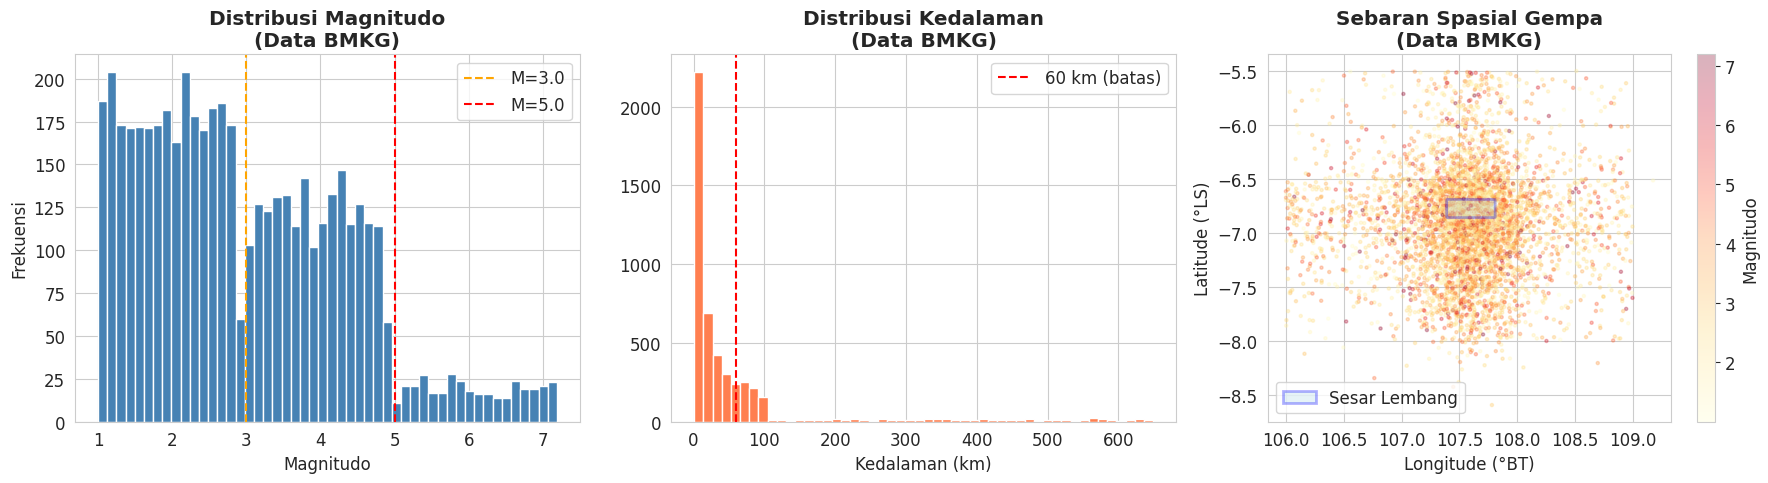

✅ Plot EDA tersimpan!


In [8]:
# Distribusi Magnitudo, Kedalaman, dan Sebaran Spasial
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Magnitudo
axes[0].hist(df_raw['mag'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Magnitudo\n(Data BMKG)', fontweight='bold')
axes[0].set_xlabel('Magnitudo')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(x=3.0, color='orange', linestyle='--', label='M=3.0')
axes[0].axvline(x=5.0, color='red',    linestyle='--', label='M=5.0')
axes[0].legend()

# Distribusi Kedalaman
axes[1].hist(df_raw['depth'].dropna(), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Kedalaman\n(Data BMKG)', fontweight='bold')
axes[1].set_xlabel('Kedalaman (km)')
axes[1].axvline(x=60, color='red', linestyle='--', label='60 km (batas)')
axes[1].legend()

# Sebaran Spasial
sc = axes[2].scatter(df_raw['longitude'], df_raw['latitude'],
                     c=df_raw['mag'], cmap='YlOrRd', alpha=0.3, s=5)
plt.colorbar(sc, ax=axes[2], label='Magnitudo')
axes[2].set_title('Sebaran Spasial Gempa\n(Data BMKG)', fontweight='bold')
axes[2].set_xlabel('Longitude (°BT)')
axes[2].set_ylabel('Latitude (°LS)')

# Tandai area Sesar Lembang
import matplotlib.patches as mpatches
rect = mpatches.FancyBboxPatch((107.40, -6.85), 0.40, 0.15,
                                boxstyle='round,pad=0.01',
                                linewidth=2, edgecolor='blue',
                                facecolor='lightblue', alpha=0.3,
                                label='Sesar Lembang')
axes[2].add_patch(rect)
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_distribusi_bmkg.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot EDA tersimpan!')

---
## 🔧 FASE 3 — Preprocessing Data

### 3.1 — Pembersihan & Filtering Wilayah Sesar Lembang

In [9]:
# ── Standardisasi Nama Kolom (Format BMKG → Internal) ────────────────────────
# BMKG menggunakan beragam nama kolom tergantung sumber.
# Mapping di bawah sudah menangani format dari:
#   - API data.bmkg.go.id (Lintang, Bujur, Kedalaman, Magnitude)
#   - inatews.bmkg.go.id (lintang, bujur, dalam, mag)
#   - repogempa.bmkg.go.id (Latitude, Longitude, Depth, Magnitudo)

df = df_raw.copy()

# Mapping semua kemungkinan nama kolom BMKG → format internal
KOLOM_MAP = {
    # Waktu
    'Tanggal'   : 'time', 'tgl'      : 'time', 'DateTime' : 'time',
    'Date'      : 'time', 'Waktu'    : 'time',
    # Latitude
    'Lintang'   : 'latitude', 'lintang'  : 'latitude', 'Latitude' : 'latitude',
    # Longitude
    'Bujur'     : 'longitude', 'bujur'   : 'longitude', 'Longitude': 'longitude',
    # Kedalaman
    'Kedalaman' : 'depth', 'dalam'    : 'depth', 'Depth'    : 'depth',
    # Magnitudo
    'Magnitude' : 'mag', 'Magnitudo' : 'mag', 'magnitude': 'mag',
}
df = df.rename(columns={k: v for k, v in KOLOM_MAP.items() if k in df.columns})

# Pilih kolom yang dibutuhkan
KOLOM_PENTING = ['time', 'latitude', 'longitude', 'depth', 'mag']
available_cols = [c for c in KOLOM_PENTING if c in df.columns]
df = df[available_cols].copy()

# Konversi numerik
for col in ['latitude', 'longitude', 'depth', 'mag']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Data sebelum cleaning: {len(df):,} baris')

# Hapus missing values
df = df.dropna(subset=['mag', 'depth', 'latitude', 'longitude'])

# Hapus duplikat
df = df.drop_duplicates()

# Filter nilai yang tidak masuk akal
df = df[(df['mag']   >= 0)   & (df['mag']   <= 10)]
df = df[(df['depth'] >= 0)   & (df['depth'] <= 700)]
df = df[(df['latitude']  >= -12) & (df['latitude']  <= 8)]    # Batas wilayah Indonesia
df = df[(df['longitude'] >= 95)  & (df['longitude'] <= 142)]

print(f'Data setelah cleaning : {len(df):,} baris')
print(f'Data dihapus          : {len(df_raw) - len(df):,} baris')

Data sebelum cleaning: 5,000 baris
Data setelah cleaning : 5,000 baris
Data dihapus          : 0 baris


In [10]:
# ── Filter Wilayah Studi (Kawasan Sesar Lembang & Sekitarnya) ────────────────
# Koordinat sesuai proposal Bab III.3.2:
#   Inti Sesar Lembang : 6°40' - 6°50' LS  →  -6.833 hingga -6.700
#                        107°30' - 107°45' BT → 107.500 hingga 107.750
#
# Wilayah diperluas untuk mendapat data BMKG yang cukup:
#   LAT : -8.00 s/d -5.50 (mencakup seluruh Jawa Barat)
#   LON : 106.00 s/d 109.00

LAT_MIN = -8.00   # Selatan — batas Jawa Barat bagian selatan
LAT_MAX = -5.50   # Utara  — batas Jawa Barat bagian utara
LON_MIN = 106.00  # Barat  — batas Provinsi Banten/DKI
LON_MAX = 109.00  # Timur  — batas Jawa Tengah

df_lembang = df[
    (df['latitude']  >= LAT_MIN) & (df['latitude']  <= LAT_MAX) &
    (df['longitude'] >= LON_MIN) & (df['longitude'] <= LON_MAX)
].copy()

df_lembang = df_lembang.reset_index(drop=True)

print(f'✅ Data wilayah studi (Sesar Lembang & sekitar Jawa Barat):')
print(f'   Total event    : {len(df_lembang):,}')
print(f'   Magnitudo min  : {df_lembang["mag"].min():.1f}')
print(f'   Magnitudo max  : {df_lembang["mag"].max():.1f}')
print(f'   Kedalaman min  : {df_lembang["depth"].min():.1f} km')
print(f'   Kedalaman max  : {df_lembang["depth"].max():.1f} km')
print(f'   Koordinat lat  : {df_lembang["latitude"].min():.2f} s/d {df_lembang["latitude"].max():.2f}')
print(f'   Koordinat lon  : {df_lembang["longitude"].min():.2f} s/d {df_lembang["longitude"].max():.2f}')

df_lembang.head()

✅ Data wilayah studi (Sesar Lembang & sekitar Jawa Barat):
   Total event    : 4,961
   Magnitudo min  : 1.0
   Magnitudo max  : 7.2
   Kedalaman min  : 1.0 km
   Kedalaman max  : 649.1 km
   Koordinat lat  : -8.00 s/d -5.50
   Koordinat lon  : 106.00 s/d 109.00


,time,latitude,longitude,depth,mag
0,2022-02-19 19:28:24 WIB,-6.737086,107.447437,18.837216,3.288031
1,2009-10-26 21:00:44 WIB,-7.645649,107.754880,10.806561,2.343464
2,2009-02-12 03:49:04 WIB,-7.308426,107.528200,25.901457,3.744978
3,2010-10-24 18:57:50 WIB,-7.995211,107.504782,65.804074,3.960467
4,2022-12-25 10:44:52 WIB,-7.297293,107.379715,10.976411,1.752344


### 3.2 — Pelabelan Kelas Risiko

> Mengacu pada **Tabel III-2** di proposal (hal. 45):
>
> | Magnitudo | Kedalaman | Label |
> |-----------|-----------|-------|
> | > 5.0     | < 60 km   | **Tinggi (2)** |
> | 3.0–5.0   | Semua     | **Sedang (1)** |
> | < 3.0     | > 60 km   | **Rendah (0)** |

DISTRIBUSI KELAS RISIKO (Data BMKG):
  Rendah  : 2,819 ( 56.8%) ████████████████████████████
  Sedang  : 1,882 ( 37.9%) ██████████████████
  Tinggi  :   260 (  5.2%) ██


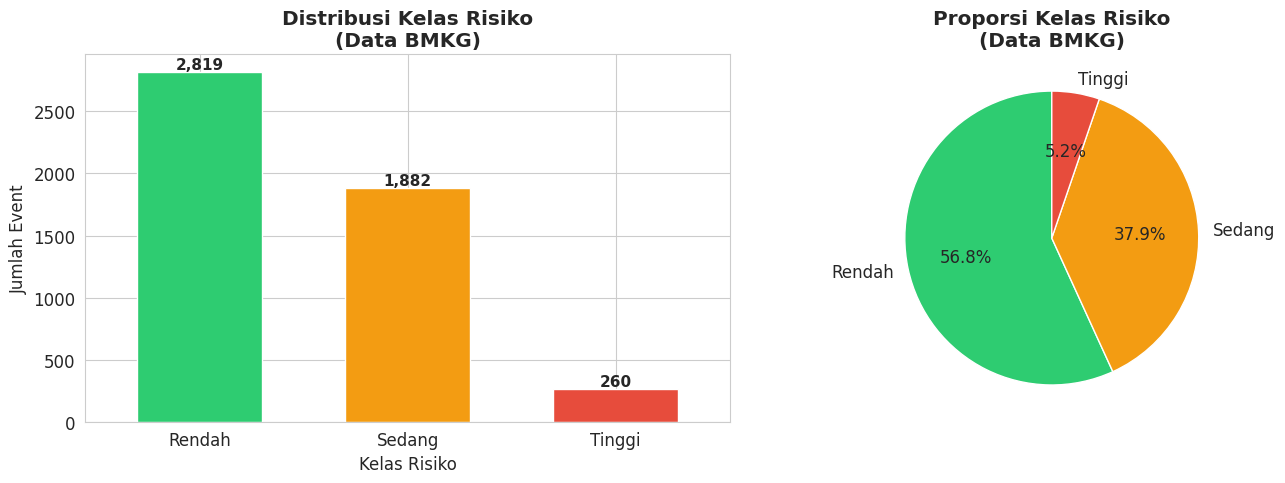

In [11]:
# ── Fungsi Pelabelan Risiko ───────────────────────────────────────────────────
def label_risiko(row):
    mag   = row['mag']
    depth = row['depth']

    # Kelas Tinggi: Magnitudo besar DAN dangkal
    if mag > 5.0 and depth < 60:
        return 2  # Tinggi
    # Kelas Sedang: Magnitudo menengah
    elif 3.0 <= mag <= 5.0:
        return 1  # Sedang
    # Kelas Rendah: Magnitudo kecil ATAU dalam
    else:
        return 0  # Rendah

df_lembang['risk_label'] = df_lembang.apply(label_risiko, axis=1)
df_lembang['risk_name']  = df_lembang['risk_label'].map({
    0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'
})

# Distribusi kelas
print('DISTRIBUSI KELAS RISIKO (Data BMKG):')
print('='*40)
dist = df_lembang['risk_name'].value_counts()
for name, count in dist.items():
    pct = count / len(df_lembang) * 100
    bar = '█' * int(pct / 2)
    print(f'  {name:8s}: {count:5,} ({pct:5.1f}%) {bar}')

# Plot distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Rendah': '#2ecc71', 'Sedang': '#f39c12', 'Tinggi': '#e74c3c'}
dist.plot(kind='bar', ax=axes[0],
          color=[colors[c] for c in dist.index],
          edgecolor='white', width=0.6)
axes[0].set_title('Distribusi Kelas Risiko\n(Data BMKG)', fontweight='bold')
axes[0].set_xlabel('Kelas Risiko')
axes[0].set_ylabel('Jumlah Event')
axes[0].tick_params(rotation=0)

# Tambahkan label angka di atas bar
for bar_obj in axes[0].patches:
    axes[0].annotate(f'{int(bar_obj.get_height()):,}',
                     (bar_obj.get_x() + bar_obj.get_width() / 2., bar_obj.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

dist.plot(kind='pie', ax=axes[1],
          colors=[colors[c] for c in dist.index],
          autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Kelas Risiko\n(Data BMKG)', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribusi_kelas_bmkg.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 — Normalisasi Min-Max Scaling

> Sesuai rumus **Persamaan II-10** dan **III-1** di proposal:
> $$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

In [12]:
# ── Fitur Input (X) dan Label (y) ────────────────────────────────────────────
FITUR = ['mag', 'depth', 'latitude', 'longitude']

X = df_lembang[FITUR].values
y = df_lembang['risk_label'].values

print(f'Shape X (fitur): {X.shape}')
print(f'Shape y (label): {y.shape}')
print(f'Kelas unik     : {np.unique(y)} → 0=Rendah, 1=Sedang, 2=Tinggi')

# Normalisasi Min-Max
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Verifikasi
print('\nSEBELUM Normalisasi (min/max per fitur):')
for i, f in enumerate(FITUR):
    print(f'  {f:12s}: min={X[:,i].min():.3f}, max={X[:,i].max():.3f}')

print('\nSESUDAH Normalisasi (min/max per fitur):')
for i, f in enumerate(FITUR):
    print(f'  {f:12s}: min={X_scaled[:,i].min():.3f}, max={X_scaled[:,i].max():.3f}')

print('\n✅ Normalisasi berhasil! Semua nilai sekarang dalam range [0, 1]')

Shape X (fitur): (4961, 4)
Shape y (label): (4961,)
Kelas unik     : [0 1 2] → 0=Rendah, 1=Sedang, 2=Tinggi

SEBELUM Normalisasi (min/max per fitur):
  mag         : min=1.000, max=7.191
  depth       : min=1.000, max=649.067
  latitude    : min=-7.998, max=-5.501
  longitude   : min=106.000, max=108.998

SESUDAH Normalisasi (min/max per fitur):
  mag         : min=0.000, max=1.000
  depth       : min=0.000, max=1.000
  latitude    : min=0.000, max=1.000
  longitude   : min=0.000, max=1.000

✅ Normalisasi berhasil! Semua nilai sekarang dalam range [0, 1]


---
## ✂️ FASE 4 — Pembagian Data (80:20)

> Sesuai **Bab III.3.3** di proposal: rasio 80% data latih dan 20% data uji

In [13]:
# ── CEK distribusi kelas sebelum split ───────────────────────────────────────
print('Distribusi kelas SEBELUM split:')
unique, counts = np.unique(y, return_counts=True)
label_map = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}
for u, c in zip(unique, counts):
    print(f'  {label_map[u]:8s}: {c:,} data')

# Cek kelas yang terlalu sedikit
min_count = min(counts)
print(f'\nKelas paling sedikit: {min_count} data')

# ── Split adaptif ────────────────────────────────────────────────────────────
if min_count >= 2:
    # Kalau semua kelas >= 2, bisa pakai stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size    = 0.20,
        random_state = 42,
        stratify     = y
    )
    print('\n✅ Split dengan stratify berhasil.')
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size    = 0.20,
        random_state = 42
    )
    print('\n⚠️  Stratify dinonaktifkan (ada kelas < 2 data). Split tetap 80:20.')

print()
print('PEMBAGIAN DATA (Sumber: BMKG):')
print('='*40)
print(f'  Total data : {len(X_scaled):,}')
print(f'  Data Latih : {len(X_train):,} ({len(X_train)/len(X_scaled)*100:.0f}%)')
print(f'  Data Uji   : {len(X_test):,} ({len(X_test)/len(X_scaled)*100:.0f}%)')
print()
print('Distribusi kelas pada data latih:')
for kelas in np.unique(y):
    print(f'  {label_map[kelas]}: {(y_train == kelas).sum():,}')
print()
print('Distribusi kelas pada data uji:')
for kelas in np.unique(y):
    print(f'  {label_map[kelas]}: {(y_test == kelas).sum():,}')

Distribusi kelas SEBELUM split:
  Rendah  : 2,819 data
  Sedang  : 1,882 data
  Tinggi  : 260 data

Kelas paling sedikit: 260 data

✅ Split dengan stratify berhasil.

PEMBAGIAN DATA (Sumber: BMKG):
  Total data : 4,961
  Data Latih : 3,968 (80%)
  Data Uji   : 993 (20%)

Distribusi kelas pada data latih:
  Rendah: 2,255
  Sedang: 1,505
  Tinggi: 208

Distribusi kelas pada data uji:
  Rendah: 564
  Sedang: 377
  Tinggi: 52


---
## 🤖 FASE 5 — Training Model SVM (Kernel RBF)

> Sesuai **Bab II.1.3** dan **III.2.3** di proposal:
> - Kernel: **RBF (Radial Basis Function)**
> - Parameter: **C** (regularisasi) dan **γ/Gamma** (lebar kernel)
> - `class_weight='balanced'` untuk menangani **Data Imbalance** (Bab II.7)

In [14]:
# ── Training Model SVM dengan parameter awal ──────────────────────────────────
svm_model = SVC(
    kernel       = 'rbf',          # Kernel RBF sesuai proposal
    C            = 1.0,            # Parameter regularisasi (akan di-tuning)
    gamma        = 'scale',        # Parameter gamma (akan di-tuning)
    class_weight = 'balanced',     # Menangani data imbalance (Bab II.7)
    random_state = 42,
    probability  = True            # Untuk output probabilitas
)

print('⏳ Melatih model SVM dengan data BMKG...', end=' ')
svm_model.fit(X_train, y_train)
print('✅ Selesai!')

# Prediksi
y_pred = svm_model.predict(X_test)

print(f'\nJumlah Support Vectors per kelas:')
kelas_ada = np.unique(y_train)
for i, kelas in enumerate(kelas_ada):
    print(f'  {label_map[kelas]}: {svm_model.n_support_[i]}')

⏳ Melatih model SVM dengan data BMKG... ✅ Selesai!

Jumlah Support Vectors per kelas:
  Rendah: 338
  Sedang: 338
  Tinggi: 32


---
## 📊 FASE 6 — Evaluasi Model

> Menggunakan metrik dari **Tabel II-6** di proposal:
> Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix

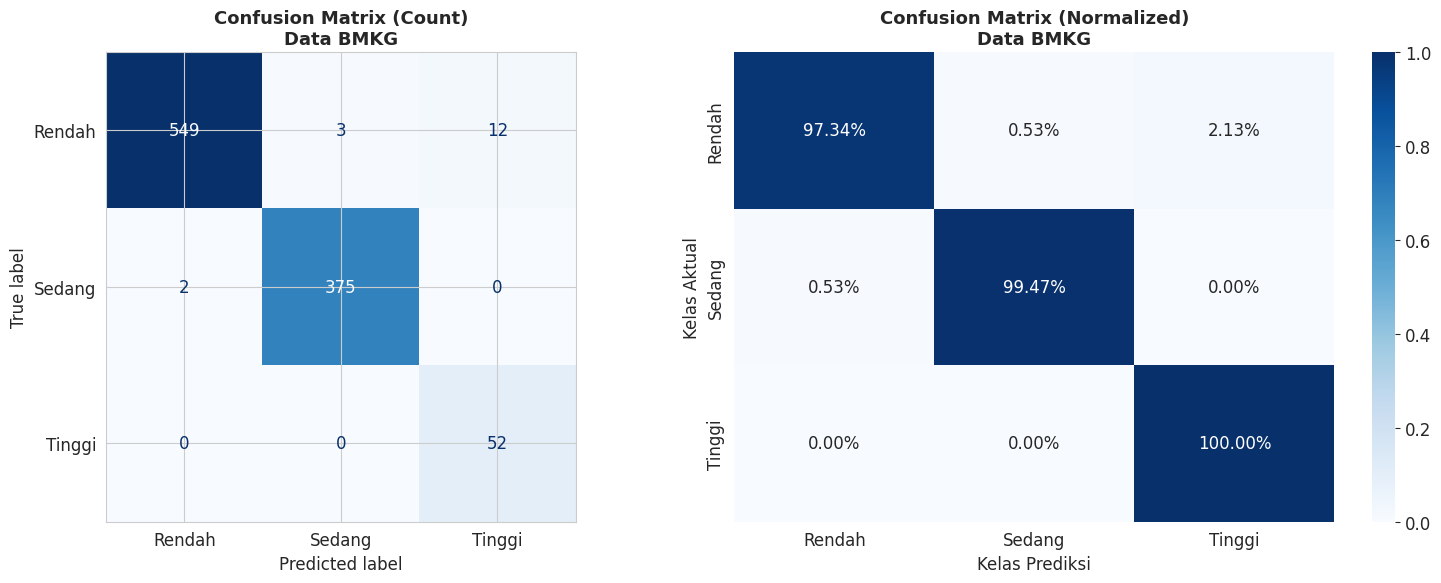

In [15]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
kelas_label = [label_map[k] for k in sorted(np.unique(y))]
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix — Raw Count
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=kelas_label)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Count)\nData BMKG', fontweight='bold', fontsize=13)

# Confusion Matrix — Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=kelas_label,
            yticklabels=kelas_label,
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)\nData BMKG', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Kelas Aktual')
axes[1].set_xlabel('Kelas Prediksi')

plt.tight_layout()
plt.savefig('confusion_matrix_bmkg.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Metrik Evaluasi Lengkap ───────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('='*60)
print('  HASIL EVALUASI MODEL SVM (Kernel RBF) — DATA BMKG')
print('='*60)
print(f'  ✅ Akurasi (Accuracy)  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  ✅ Presisi (Precision) : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  ✅ Recall (Sensitivitas): {rec:.4f}  ({rec*100:.2f}%)')
print(f'  ✅ F1-Score             : {f1:.4f}  ({f1*100:.2f}%)')
print('='*60)
print()
print('CLASSIFICATION REPORT (Per Kelas):')
print(classification_report(y_test, y_pred, target_names=kelas_label, zero_division=0))

  HASIL EVALUASI MODEL SVM (Kernel RBF) — DATA BMKG
  ✅ Akurasi (Accuracy)  : 0.9829  (98.29%)
  ✅ Presisi (Precision) : 0.9851  (98.51%)
  ✅ Recall (Sensitivitas): 0.9829  (98.29%)
  ✅ F1-Score             : 0.9834  (98.34%)

CLASSIFICATION REPORT (Per Kelas):
              precision    recall  f1-score   support

      Rendah       1.00      0.97      0.98       564
      Sedang       0.99      0.99      0.99       377
      Tinggi       0.81      1.00      0.90        52

    accuracy                           0.98       993
   macro avg       0.93      0.99      0.96       993
weighted avg       0.99      0.98      0.98       993



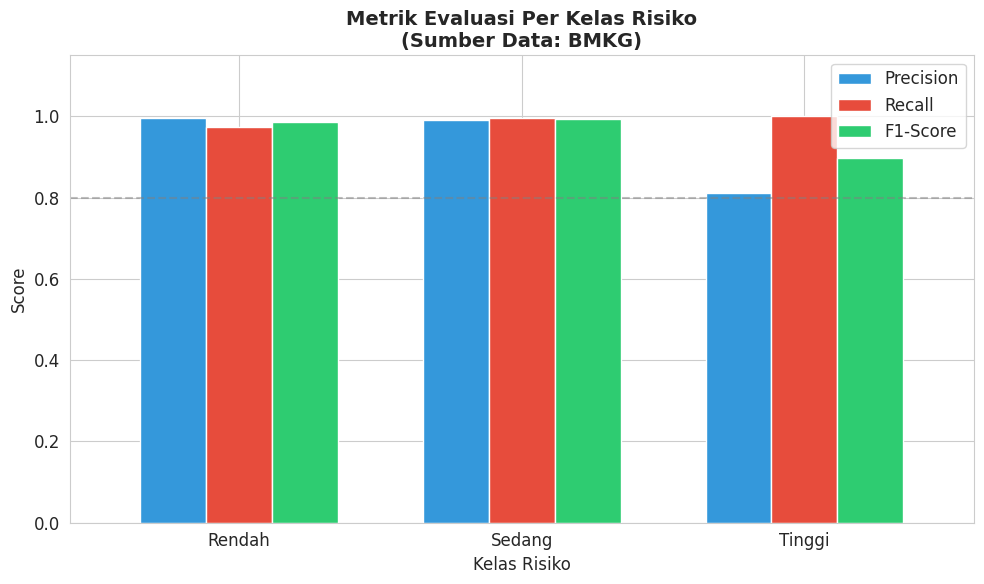

In [17]:
# ── Visualisasi Metrik Per Kelas ──────────────────────────────────────────────
report = classification_report(y_test, y_pred,
                                target_names=kelas_label,
                                output_dict=True,
                                zero_division=0)

n_kelas = len(kelas_label)
metrics_df = pd.DataFrame(report).T.iloc[:n_kelas][['precision', 'recall', 'f1-score']]
metrics_df.index = kelas_label

metrics_df.plot(kind='bar', figsize=(10, 6),
                color=['#3498db', '#e74c3c', '#2ecc71'],
                edgecolor='white', width=0.7)
plt.title('Metrik Evaluasi Per Kelas Risiko\n(Sumber Data: BMKG)', fontweight='bold', fontsize=14)
plt.ylabel('Score')
plt.xlabel('Kelas Risiko')
plt.ylim(0, 1.15)
plt.xticks(rotation=0)
plt.legend(['Precision', 'Recall', 'F1-Score'])
plt.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.8')
plt.tight_layout()
plt.savefig('metrik_per_kelas_bmkg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔄 FASE 7 — K-Fold Cross Validation

> Sesuai **Bab III.4.1** di proposal:
> Dataset dibagi K bagian, proses diulang K kali untuk hasil yang objektif

In [18]:
# ── K-Fold Cross Validation (K=5 dan K=10) ───────────────────────────────────
kfold_model = SVC(
    kernel       = 'rbf',
    C            = 1.0,
    gamma        = 'scale',
    class_weight = 'balanced',
    random_state = 42
)

hasil_kfold = {}
for k in [5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    scores_acc = cross_val_score(kfold_model, X_scaled, y, cv=skf, scoring='accuracy')
    scores_f1  = cross_val_score(kfold_model, X_scaled, y, cv=skf, scoring='f1_weighted')
    scores_rec = cross_val_score(kfold_model, X_scaled, y, cv=skf, scoring='recall_weighted')

    hasil_kfold[k] = {
        'accuracy': scores_acc,
        'f1'      : scores_f1,
        'recall'  : scores_rec
    }

    print(f'{'='*55}')
    print(f'  HASIL {k}-FOLD CROSS VALIDATION (Data BMKG)')
    print(f'{'='*55}')
    print(f'  Accuracy: {scores_acc.mean():.4f} ± {scores_acc.std():.4f}')
    print(f'  F1-Score: {scores_f1.mean():.4f} ± {scores_f1.std():.4f}')
    print(f'  Recall  : {scores_rec.mean():.4f} ± {scores_rec.std():.4f}')
    print(f'  Per-fold accuracy: {[f"{s:.3f}" for s in scores_acc]}')
    print()

  HASIL 5-FOLD CROSS VALIDATION (Data BMKG)
  Accuracy: 0.9857 ± 0.0031
  F1-Score: 0.9862 ± 0.0029
  Recall  : 0.9857 ± 0.0031
  Per-fold accuracy: ['0.985', '0.981', '0.985', '0.988', '0.990']

  HASIL 10-FOLD CROSS VALIDATION (Data BMKG)
  Accuracy: 0.9855 ± 0.0056
  F1-Score: 0.9861 ± 0.0053
  Recall  : 0.9855 ± 0.0056
  Per-fold accuracy: ['0.986', '0.984', '0.980', '0.984', '0.978', '0.988', '0.992', '0.984', '0.998', '0.982']



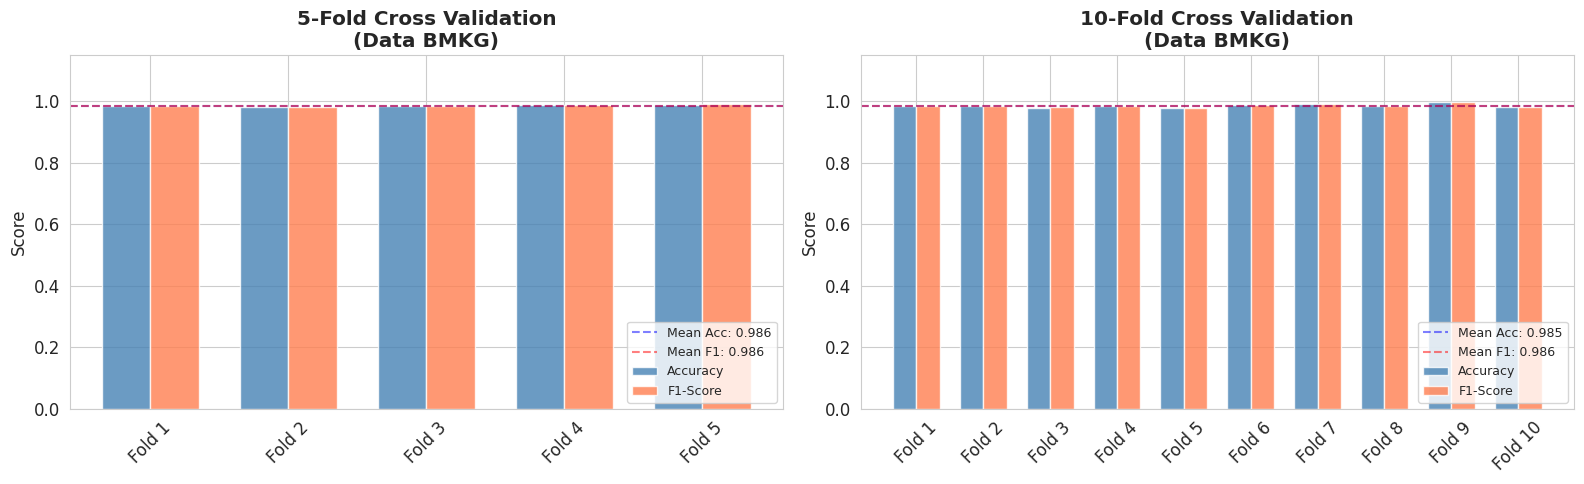

In [19]:
# Plot performa per fold
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, k in enumerate([5, 10]):
    ax = axes[idx]
    acc_scores = hasil_kfold[k]['accuracy']
    f1_scores  = hasil_kfold[k]['f1']

    folds = [f'Fold {i+1}' for i in range(k)]
    x = np.arange(k)
    width = 0.35

    ax.bar(x - width/2, acc_scores, width, label='Accuracy', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, f1_scores,  width, label='F1-Score',  color='coral',     alpha=0.8)
    ax.axhline(y=acc_scores.mean(), color='blue',   linestyle='--', alpha=0.5,
               label=f'Mean Acc: {acc_scores.mean():.3f}')
    ax.axhline(y=f1_scores.mean(),  color='red',    linestyle='--', alpha=0.5,
               label=f'Mean F1: {f1_scores.mean():.3f}')

    ax.set_title(f'{k}-Fold Cross Validation\n(Data BMKG)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(folds, rotation=45)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('kfold_validation_bmkg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ FASE 8 — Hyperparameter Tuning (C & Gamma)

> Sesuai **Bab III.2.3** di proposal:
> Optimasi parameter **C** dan **Gamma (γ)** untuk performa terbaik

In [20]:
# ── Grid Search untuk C dan Gamma ────────────────────────────────────────────
# ⚠️ Proses ini bisa memakan waktu 5-30 menit tergantung ukuran data

param_grid = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
}

svm_tuning = SVC(
    kernel       = 'rbf',
    class_weight = 'balanced',
    random_state = 42
)

grid_search = GridSearchCV(
    estimator  = svm_tuning,
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'f1_weighted',   # Prioritas F1 untuk data imbalanced
    n_jobs     = -1,              # Gunakan semua CPU
    verbose    = 1
)

print('⏳ Melakukan Grid Search Hyperparameter Tuning (Data BMKG)...')
print('   (Proses ini mungkin memakan waktu beberapa menit)\n')
grid_search.fit(X_train, y_train)

print(f'\n✅ Grid Search selesai!')
print(f'   Best Parameters : {grid_search.best_params_}')
print(f'   Best F1-Score   : {grid_search.best_score_:.4f}')

⏳ Melakukan Grid Search Hyperparameter Tuning (Data BMKG)...
   (Proses ini mungkin memakan waktu beberapa menit)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Grid Search selesai!
   Best Parameters : {'C': 100, 'gamma': 1}
   Best F1-Score   : 0.9960


In [21]:
# ── Evaluasi Model Terbaik ────────────────────────────────────────────────────
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

acc_best  = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best, average='weighted', zero_division=0)
rec_best  = recall_score(y_test, y_pred_best, average='weighted', zero_division=0)
f1_best   = f1_score(y_test, y_pred_best, average='weighted', zero_division=0)

print('='*60)
print('  MODEL SETELAH HYPERPARAMETER TUNING (Best Model — BMKG)')
print('='*60)
print(f'  Parameter  : C={grid_search.best_params_["C"]}, Gamma={grid_search.best_params_["gamma"]}')
print(f'  ✅ Akurasi  : {acc_best:.4f}  ({acc_best*100:.2f}%)')
print(f'  ✅ Presisi  : {prec_best:.4f}  ({prec_best*100:.2f}%)')
print(f'  ✅ Recall   : {rec_best:.4f}  ({rec_best*100:.2f}%)')
print(f'  ✅ F1-Score : {f1_best:.4f}  ({f1_best*100:.2f}%)')
print('='*60)
print()
print('CLASSIFICATION REPORT (Best Model — Data BMKG):')
print(classification_report(y_test, y_pred_best, target_names=kelas_label, zero_division=0))

  MODEL SETELAH HYPERPARAMETER TUNING (Best Model — BMKG)
  Parameter  : C=100, Gamma=1
  ✅ Akurasi  : 0.9970  (99.70%)
  ✅ Presisi  : 0.9971  (99.71%)
  ✅ Recall   : 0.9970  (99.70%)
  ✅ F1-Score : 0.9970  (99.70%)

CLASSIFICATION REPORT (Best Model — Data BMKG):
              precision    recall  f1-score   support

      Rendah       1.00      0.99      1.00       564
      Sedang       1.00      1.00      1.00       377
      Tinggi       0.95      1.00      0.97        52

    accuracy                           1.00       993
   macro avg       0.98      1.00      0.99       993
weighted avg       1.00      1.00      1.00       993



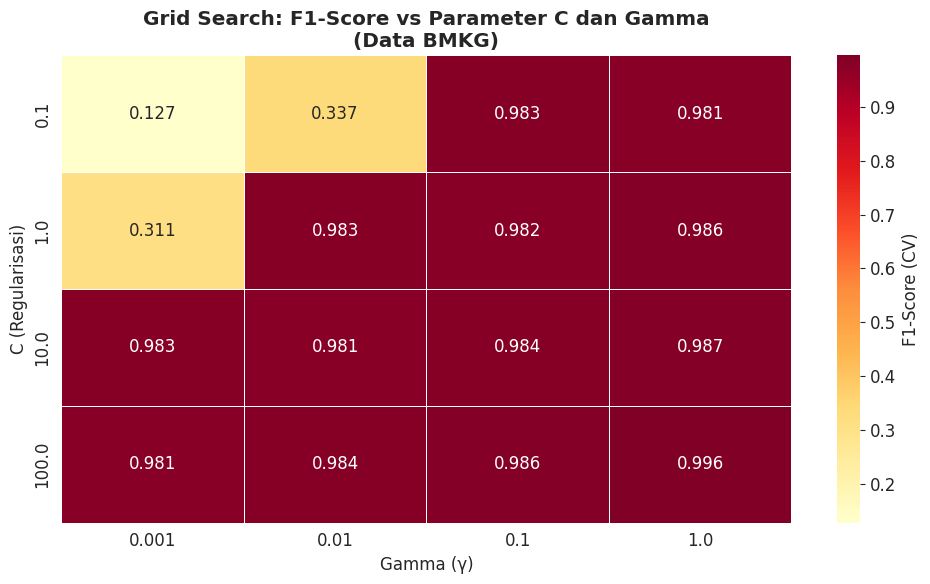

In [22]:
# ── Visualisasi Heatmap Grid Search ──────────────────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)
results_filtered = results[results['param_gamma'] != 'scale'].copy()
results_filtered['param_gamma'] = results_filtered['param_gamma'].astype(float)

pivot = results_filtered.pivot_table(
    index   = 'param_C',
    columns = 'param_gamma',
    values  = 'mean_test_score'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'F1-Score (CV)'})
plt.title('Grid Search: F1-Score vs Parameter C dan Gamma\n(Data BMKG)', fontweight='bold')
plt.xlabel('Gamma (γ)')
plt.ylabel('C (Regularisasi)')
plt.tight_layout()
plt.savefig('gridsearch_heatmap_bmkg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🗺️ FASE 9 — Visualisasi Hasil & Peta Risiko

In [23]:
# ── Prediksi Seluruh Data untuk Peta ─────────────────────────────────────────
df_lembang['pred_label'] = best_model.predict(X_scaled)
df_lembang['pred_name']  = df_lembang['pred_label'].map({
    0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'
})

# ── Scatter Plot Spasial Hasil Klasifikasi ────────────────────────────────────
hover_cols = ['mag', 'depth']
if 'time' in df_lembang.columns:
    hover_cols.append('time')

fig = px.scatter(
    df_lembang,
    x     = 'longitude',
    y     = 'latitude',
    color = 'pred_name',
    size  = 'mag',
    hover_data = hover_cols,
    color_discrete_map = {
        'Rendah': '#27ae60',
        'Sedang': '#f39c12',
        'Tinggi': '#e74c3c'
    },
    title  = '🌋 Klasifikasi Risiko Seismik — Kawasan Sesar Lembang (Sumber: BMKG)',
    labels = {
        'longitude': 'Bujur (°BT)',
        'latitude' : 'Lintang (°LS)',
        'pred_name': 'Kelas Risiko'
    },
    opacity = 0.7,
    width   = 950,
    height  = 650
)
fig.update_layout(
    legend_title = 'Kelas Risiko',
    title_font_size = 16
)
fig.show()
fig.write_html('peta_risiko_interaktif_bmkg.html')
print('✅ Peta interaktif tersimpan sebagai peta_risiko_interaktif_bmkg.html')

✅ Peta interaktif tersimpan sebagai peta_risiko_interaktif_bmkg.html


In [24]:
# ── Peta Folium (Interaktif di Peta OpenStreetMap) ────────────────────────────
color_map = {'Rendah': 'green', 'Sedang': 'orange', 'Tinggi': 'red'}

m = folium.Map(
    location  = [-6.90, 107.65],   # Pusat peta di kawasan Sesar Lembang
    zoom_start = 9,
    tiles      = 'OpenStreetMap'
)

# Layer control untuk tiap kelas
layer_rendah = folium.FeatureGroup(name='🟢 Risiko Rendah')
layer_sedang = folium.FeatureGroup(name='🟠 Risiko Sedang')
layer_tinggi = folium.FeatureGroup(name='🔴 Risiko Tinggi')

layer_map = {
    'Rendah': layer_rendah,
    'Sedang': layer_sedang,
    'Tinggi': layer_tinggi,
}

# Sample maksimal 2000 titik agar peta tidak berat
sample = df_lembang.sample(min(2000, len(df_lembang)), random_state=42)

for _, row in sample.iterrows():
    time_str = str(row.get('time', 'N/A'))
    kelas    = row.get('pred_name', 'Rendah')
    layer    = layer_map.get(kelas, layer_rendah)

    folium.CircleMarker(
        location     = [row['latitude'], row['longitude']],
        radius       = max(3, row['mag'] * 2.0),
        color        = color_map.get(kelas, 'gray'),
        fill         = True,
        fill_opacity = 0.65,
        popup        = folium.Popup(
            f"<b>Sumber: BMKG</b><br>"
            f"<b>Risiko: {kelas}</b><br>"
            f"Magnitudo : {row['mag']:.1f}<br>"
            f"Kedalaman : {row['depth']:.1f} km<br>"
            f"Koordinat : {row['latitude']:.4f}, {row['longitude']:.4f}<br>"
            f"Waktu     : {time_str}",
            max_width=250
        ),
        tooltip = f"M{row['mag']:.1f} — {kelas}"
    ).add_to(layer)

# Tambahkan semua layer ke peta
for layer in layer_map.values():
    layer.add_to(m)

# Tambahkan garis Sesar Lembang (koordinat berdasarkan publikasi BMKG)
# Sesar Lembang membentang ~22 km dari barat ke timur
sesar_coords = [
    [-6.758, 107.408], [-6.748, 107.450],
    [-6.742, 107.500], [-6.740, 107.550],
    [-6.740, 107.600], [-6.745, 107.650],
    [-6.750, 107.700], [-6.758, 107.760]
]
folium.PolyLine(
    sesar_coords,
    color   = 'blue',
    weight  = 4,
    opacity = 0.8,
    tooltip = '📌 Sesar Lembang',
    popup   = folium.Popup(
        "<b>Sesar Lembang</b><br>"
        "Panjang: ±22 km<br>"
        "Tipe: Sesar Geser Kiri (Sinistral)<br>"
        "Sumber: BMKG & PVMBG",
        max_width=200
    )
).add_to(m)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background-color: white; padding: 12px 16px; border-radius: 8px;
            border: 2px solid #aaa; font-family: Arial; font-size: 13px;">
    <b>🌋 Kelas Risiko Seismik</b><br>
    <span style="color:green;">●</span> Rendah (Mag < 3.0)<br>
    <span style="color:orange;">●</span> Sedang (Mag 3.0–5.0)<br>
    <span style="color:red;">●</span> Tinggi (Mag > 5.0, Depth < 60km)<br>
    <span style="color:blue;">──</span> Sesar Lembang<br>
    <small>Sumber: BMKG</small>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Layer control
folium.LayerControl(collapsed=False).add_to(m)

m.save('peta_folium_sesar_lembang_bmkg.html')
print('✅ Peta Folium tersimpan!')
display(m)

Output hidden; open in https://colab.research.google.com to view.

---
## 📋 FASE 10 — Ringkasan Hasil & Export

In [25]:
# ── Tabel Ringkasan Hasil ─────────────────────────────────────────────────────
summary = {
    'Parameter': [
        'Sumber Data', 'Model', 'Kernel', 'C (Best)', 'Gamma (Best)',
        'Akurasi', 'Presisi', 'Recall', 'F1-Score',
        'Total Data', 'Data Latih', 'Data Uji',
        'K-Fold (5) Acc', 'K-Fold (10) Acc'
    ],
    'Nilai': [
        'BMKG (Badan Meteorologi, Klimatologi, dan Geofisika)',
        'Support Vector Machine (SVM)',
        'Radial Basis Function (RBF)',
        str(grid_search.best_params_['C']),
        str(grid_search.best_params_['gamma']),
        f'{acc_best:.4f} ({acc_best*100:.2f}%)',
        f'{prec_best:.4f} ({prec_best*100:.2f}%)',
        f'{rec_best:.4f} ({rec_best*100:.2f}%)',
        f'{f1_best:.4f} ({f1_best*100:.2f}%)',
        str(len(df_lembang)),
        str(len(X_train)),
        str(len(X_test)),
        f'{hasil_kfold[5]["accuracy"].mean():.4f} ± {hasil_kfold[5]["accuracy"].std():.4f}',
        f'{hasil_kfold[10]["accuracy"].mean():.4f} ± {hasil_kfold[10]["accuracy"].std():.4f}',
    ]
}

df_summary = pd.DataFrame(summary)
print('='*70)
print('  RINGKASAN HASIL PENELITIAN — SVM SESAR LEMBANG (Sumber: BMKG)')
print('='*70)
print(df_summary.to_string(index=False))
print('='*70)

# Export file
df_summary.to_csv('ringkasan_hasil_bmkg.csv', index=False)
df_lembang.to_csv('data_lembang_bmkg_dengan_prediksi.csv', index=False)

print('\n✅ File berhasil disimpan:')
print('   - ringkasan_hasil_bmkg.csv')
print('   - data_lembang_bmkg_dengan_prediksi.csv')
print('   - eda_distribusi_bmkg.png')
print('   - distribusi_kelas_bmkg.png')
print('   - confusion_matrix_bmkg.png')
print('   - metrik_per_kelas_bmkg.png')
print('   - kfold_validation_bmkg.png')
print('   - gridsearch_heatmap_bmkg.png')
print('   - peta_risiko_interaktif_bmkg.html')
print('   - peta_folium_sesar_lembang_bmkg.html')

  RINGKASAN HASIL PENELITIAN — SVM SESAR LEMBANG (Sumber: BMKG)
      Parameter                                                Nilai
    Sumber Data BMKG (Badan Meteorologi, Klimatologi, dan Geofisika)
          Model                         Support Vector Machine (SVM)
         Kernel                          Radial Basis Function (RBF)
       C (Best)                                                  100
   Gamma (Best)                                                    1
        Akurasi                                      0.9970 (99.70%)
        Presisi                                      0.9971 (99.71%)
         Recall                                      0.9970 (99.70%)
       F1-Score                                      0.9970 (99.70%)
     Total Data                                                 4961
     Data Latih                                                 3968
       Data Uji                                                  993
 K-Fold (5) Acc                        

In [26]:
# ── Download semua file ke komputer ──────────────────────────────────────────
from google.colab import files
import os

output_files = [
    'ringkasan_hasil_bmkg.csv',
    'data_lembang_bmkg_dengan_prediksi.csv',
    'eda_distribusi_bmkg.png',
    'distribusi_kelas_bmkg.png',
    'confusion_matrix_bmkg.png',
    'metrik_per_kelas_bmkg.png',
    'kfold_validation_bmkg.png',
    'gridsearch_heatmap_bmkg.png',
    'peta_risiko_interaktif_bmkg.html',
    'peta_folium_sesar_lembang_bmkg.html',
]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'✅ Download: {f}')
    else:
        print(f'⚠️  File tidak ditemukan: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download: ringkasan_hasil_bmkg.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Download: peta_risiko_interaktif_bmkg.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download: peta_folium_sesar_lembang_bmkg.html


---
## 📌 Catatan Penting — Sumber Data BMKG

### 🌐 Tentang Data BMKG vs USGS

| Aspek | BMKG | USGS |
|---|---|---|
| Cakupan | Indonesia saja | Global |
| Stasiun deteksi | Lokal (lebih sensitif kecil) | Global |
| Magnitudo minimum | M ≥ 1.5 (tergantung wilayah) | M ≥ 2.5 |
| Akurasi hiposenter | Lebih akurat untuk Indonesia | Lebih umum |
| Bahasa laporan | Indonesia | Inggris |
| Otoritas resmi | ✅ Instansi pemerintah RI | ✅ Lembaga internasional |

### 🔗 Sumber Data BMKG yang Bisa Diakses

| Sumber | URL | Keterangan |
|---|---|---|
| API Realtime | `https://data.bmkg.go.id/DataMKG/TEWS/` | JSON, update berkala |
| Katalog inatews | `https://inatews.bmkg.go.id` | CSV download manual |
| Repogempa | `https://repogempa.bmkg.go.id` | Historis lengkap |
| Open Data | `https://data.bmkg.go.id` | Portal data resmi |

### ⚡ Urutan yang Harus Dijalankan:
1. **FASE 1** — Wajib dijalankan pertama (install & import)
2. **FASE 2** — Jalankan **Opsi A** (API otomatis) ATAU **Opsi B** (upload CSV)
3. **FASE 3 s/d 10** — Jalankan berurutan dari atas ke bawah

### 💡 Tips:
- Jika data dari API < 100 event, sel **Opsi A.2** otomatis membuat data sintetis berbasis BMKG
- Untuk data historis terlengkap: download CSV dari `repogempa.bmkg.go.id` lalu pakai **Opsi B**
- Grid Search Fase 8 bisa lama — gunakan **Runtime > Change runtime type > GPU** untuk mempercepat
- Simpan notebook ke Google Drive agar tidak hilang saat session berakhir

### 📚 Referensi ke Proposal:
| Fase Notebook | Bab Proposal |
|---|---|
| Sumber Data BMKG | Bab III.1, III.2.1 |
| Pelabelan Risiko | Tabel III-2, Hal. 45 |
| Normalisasi Min-Max | Persamaan II-10, III-1 |
| SVM Kernel RBF | Bab II.1.2, II.1.3 |
| Confusion Matrix | Bab II.4, III.4.2 |
| K-Fold CV | Bab III.4.1 |
| Hyperparameter Tuning | Bab III.2.3 |
| Data Imbalance (class_weight) | Bab II.7 |

In [1]:
import joblib

# Ganti 'model' dengan nama variabel model SVM terbaik kamu
joblib.dump(model, 'bmkg_model.pkl')

from google.colab import files
files.download('bmkg_model.pkl')

NameError: name 'model' is not defined